## Medical Disease Prediction System

### Diabetes Risk Prediction

This notebook develops an end-to-end machine learning pipeline for predicting diabetes risk using patient clinical parameters.

#### Objectives
- Understand and explore the dataset
- Clean and preprocess the data
- Perform exploratory data analysis
- Engineer relevant features
- Train multiple classification models
- Compare model performance
- Select the best-performing model
- Prepare the model for deployment

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

In [2]:
df = pd.read_csv("../data/diabetes.csv")

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
df.shape

(768, 9)

In [4]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='str')

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [6]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [7]:
df["Outcome"].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

In [8]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

#### 1. Exploratory Data Analysis

Before building the prediction models, we analyze the dataset to understand its structure, quality, distributions, and relationships between variables.

In [9]:
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

Number of rows: 768
Number of columns: 9


In [10]:
df.dtypes

Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df[df.duplicated()]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome


In [13]:
missing_values = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": (df.isnull().sum() / len(df)) * 100
})

missing_values

,Missing Values,Percentage
Pregnancies,0,0.0
Glucose,0,0.0
BloodPressure,0,0.0
SkinThickness,0,0.0
Insulin,0,0.0
BMI,0,0.0
DiabetesPedigreeFunction,0,0.0
Age,0,0.0
Outcome,0,0.0


In [14]:
features_with_zero = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

(df[features_with_zero] == 0).sum()

Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64

In [15]:
outcome_counts = df["Outcome"].value_counts()

print(outcome_counts)

Outcome
0    500
1    268
Name: count, dtype: int64


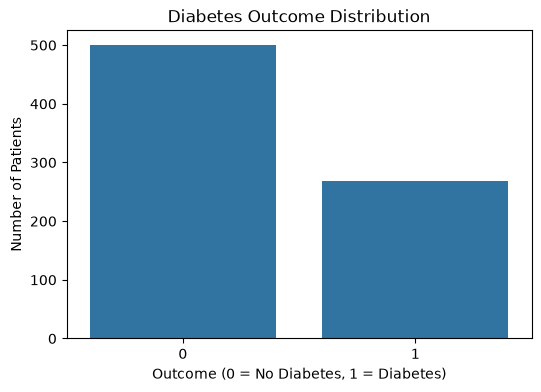

In [16]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="Outcome")

plt.title("Diabetes Outcome Distribution")
plt.xlabel("Outcome (0 = No Diabetes, 1 = Diabetes)")
plt.ylabel("Number of Patients")

plt.show()

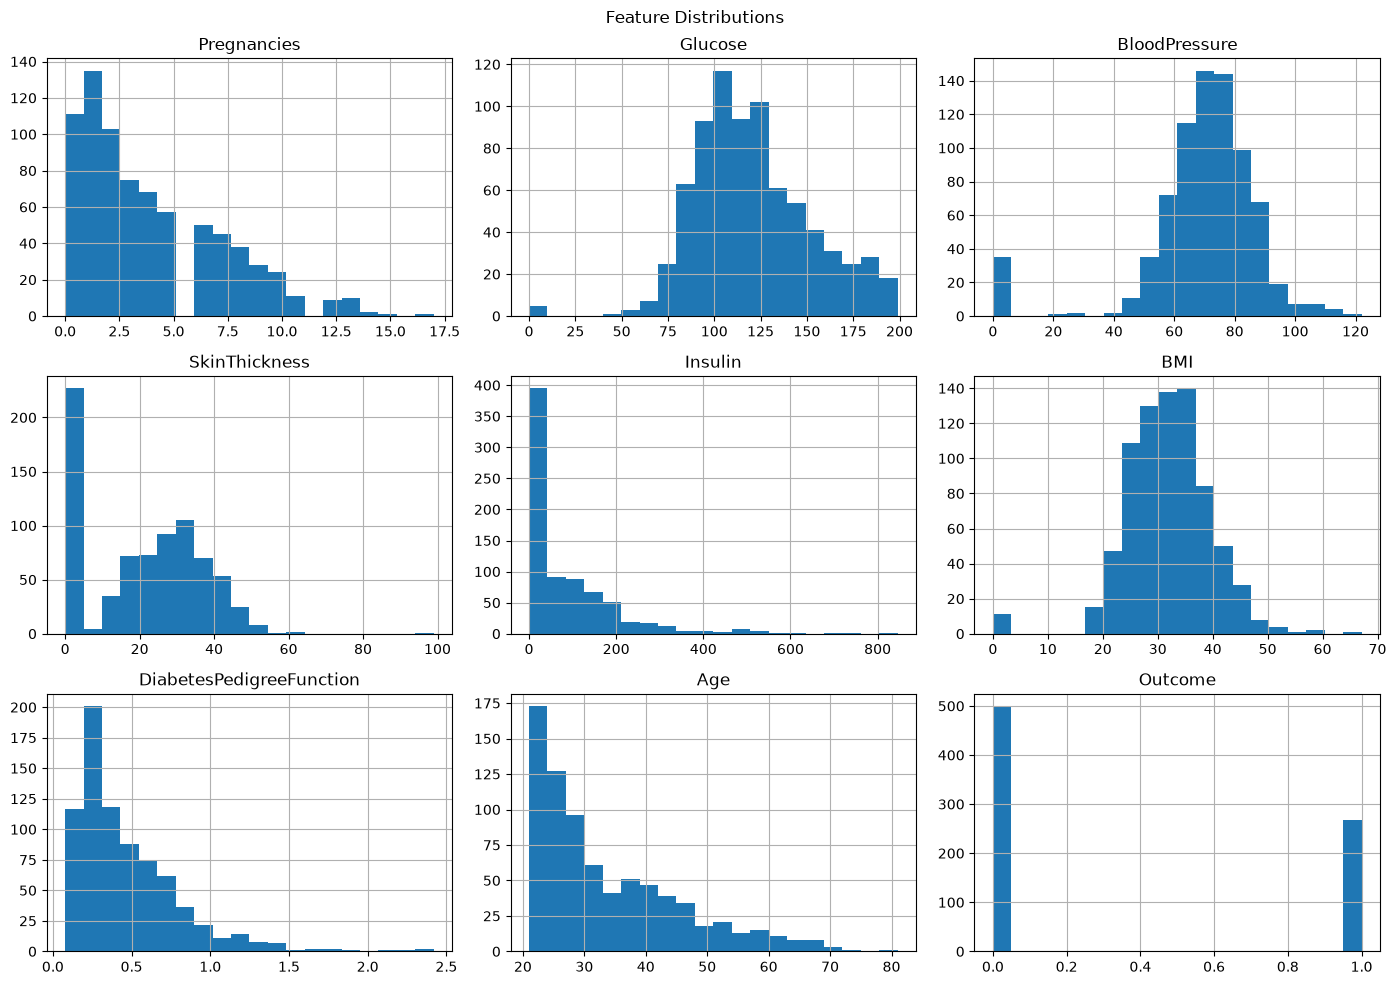

In [17]:
df.hist(
    figsize=(14, 10),
    bins=20
)

plt.suptitle("Feature Distributions")
plt.tight_layout()
plt.show()

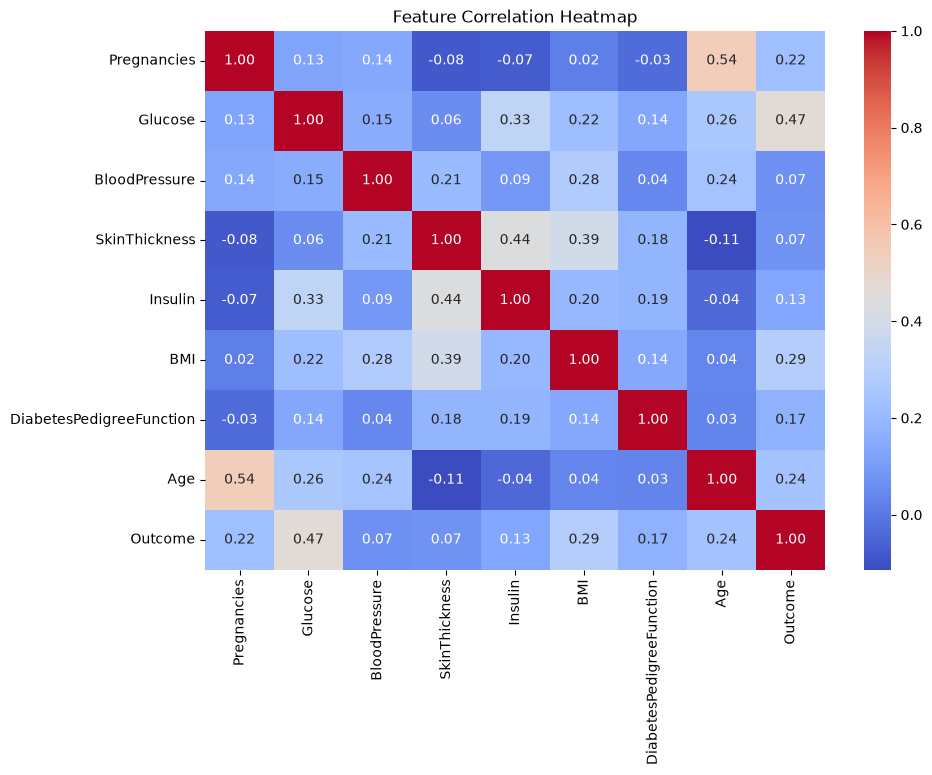

In [18]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Feature Correlation Heatmap")
plt.show()

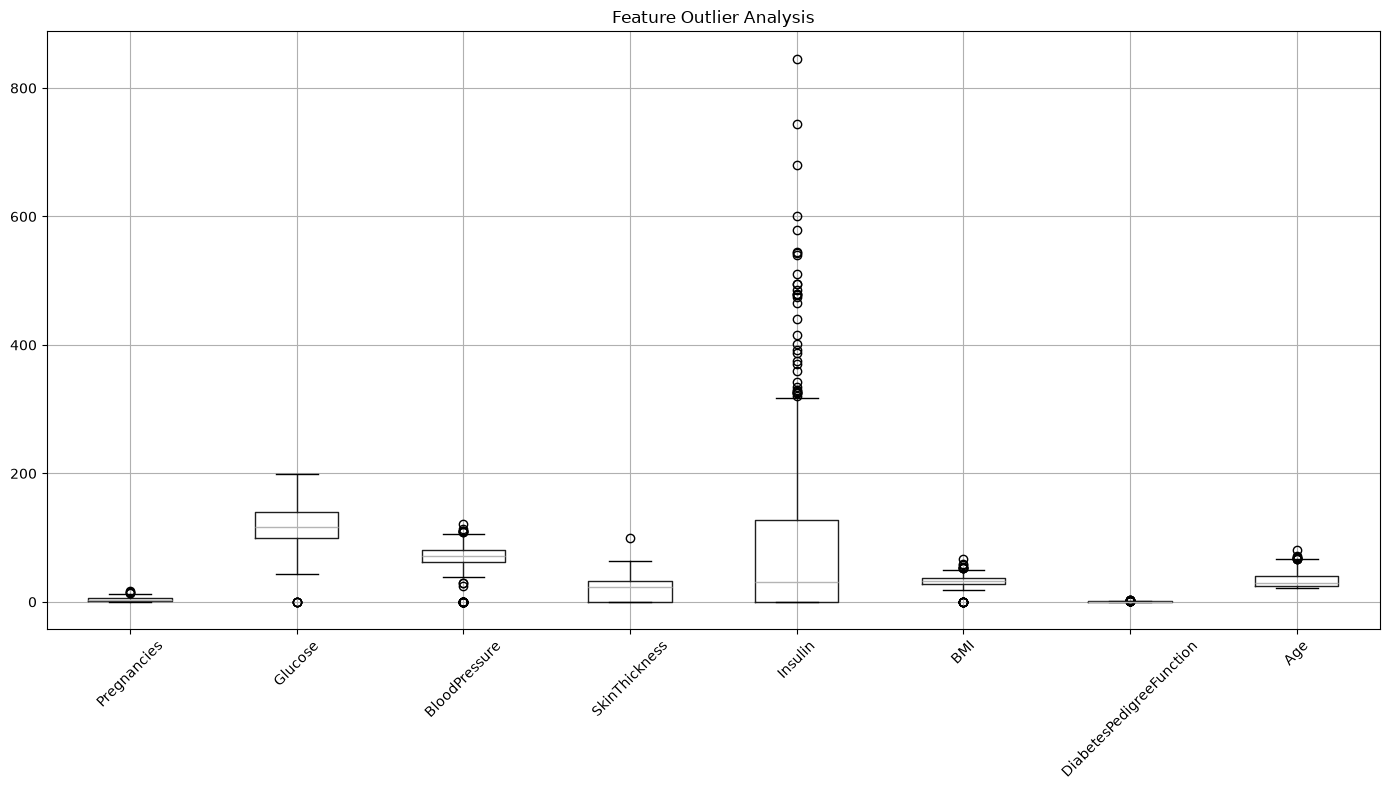

In [19]:
plt.figure(figsize=(14, 8))

df.drop(columns="Outcome").boxplot()

plt.title("Feature Outlier Analysis")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

#### EDA Findings

- The dataset contains 768 patient records and 8 predictive features.
- No explicit NaN values are present in the dataset.
- Several clinical variables contain zero values that are physiologically implausible and require treatment as missing values.
- The target variable contains two classes: diabetic and non-diabetic.
- Feature distributions show variation in clinical measurements and the presence of potential outliers.
- Glucose shows a noticeable relationship with the diabetes outcome.
- Correlation analysis helps identify relationships among the clinical features and target variable.

#### 2. Data Preprocessing

The preprocessing stage prepares the clinical features for machine learning by handling invalid values, separating the target variable, splitting the dataset, and applying feature scaling without introducing data leakage.

In [20]:
df_processed = df.copy()

In [21]:
invalid_zero_columns = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

df_processed[invalid_zero_columns] = (
    df_processed[invalid_zero_columns]
    .replace(0, np.nan)
)

In [22]:
df_processed.isnull().sum()

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

In [23]:
for column in invalid_zero_columns:
    df_processed[column] = df_processed[column].fillna(
        df_processed[column].median()
    )

In [24]:
df_processed.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [25]:
X = df_processed.drop("Outcome", axis=1)
y = df_processed["Outcome"]

print("Features:", X.shape)
print("Target:", y.shape)

Features: (768, 8)
Target: (768,)


In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [27]:
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True))

Training samples: 614
Testing samples: 154

Training target distribution:
Outcome
0    0.651466
1    0.348534
Name: proportion, dtype: float64

Testing target distribution:
Outcome
0    0.649351
1    0.350649
Name: proportion, dtype: float64


In [28]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [29]:
X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X_test.columns,
    index=X_test.index
)

In [30]:
X_train_scaled.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
353,-0.851355,-1.056427,-0.826740,-1.918187,-1.203361,-0.769477,0.310794,-0.792169
711,0.356576,0.144399,0.477772,-0.229874,-1.470195,-0.417498,-0.116439,0.561034
373,-0.549372,-0.556083,-1.152868,1.233330,-0.555335,0.359790,-0.764862,-0.707594
46,-0.851355,0.811525,-1.315932,-0.004766,-0.161437,-0.402832,0.262314,-0.369293
682,-1.153338,-0.889646,-0.663676,1.120776,-0.415565,1.782373,-0.337630,-0.961320


In [31]:
X_train_scaled.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,614.0,-6.943414e-17,1.000815,-1.153338,-0.851355,-0.247390,0.658558,3.980368
Glucose,614.0,-1.099374e-16,1.000815,-2.190541,-0.756221,-0.155808,0.611387,2.579408
BloodPressure,614.0,3.095606e-16,1.000815,-3.924957,-0.663676,-0.011420,0.640836,4.065181
SkinThickness,614.0,-3.471707e-17,1.000815,-2.480958,-0.454983,-0.004766,0.332896,7.874025
Insulin,614.0,-4.339634e-18,1.000815,-1.559139,-0.224969,-0.161437,-0.097905,7.703814
BMI,614.0,-1.148556e-15,1.000815,-2.089399,-0.707147,-0.021521,0.594443,5.082179
DiabetesPedigreeFunction,614.0,-1.099374e-16,1.000815,-1.192094,-0.704262,-0.287634,0.490322,5.610293
Age,614.0,-1.084908e-16,1.000815,-1.045895,-0.792169,-0.369293,0.645609,4.028617


In [32]:
print("Missing values in training data:")
print(X_train_scaled.isnull().sum().sum())

print("\nMissing values in test data:")
print(X_test_scaled.isnull().sum().sum())

Missing values in training data:
0

Missing values in test data:
0


#### Preprocessing Summary

- Created a separate copy of the raw dataset to preserve the original data.
- Identified physiologically implausible zero values in selected clinical features.
- Replaced invalid zero values with missing values and applied median imputation.
- Separated the eight clinical features from the target variable.
- Split the dataset into training and testing sets using stratified sampling.
- Applied StandardScaler by fitting only on the training data to prevent data leakage.

#### 3. Model Development

Multiple classification algorithms are trained and evaluated to identify the most suitable model for diabetes risk prediction.

The following models are compared:

- Logistic Regression
- Decision Tree
- Random Forest

In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [34]:
logistic_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

decision_tree_model = DecisionTreeClassifier(
    random_state=42
)

random_forest_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

In [35]:
logistic_model.fit(X_train_scaled, y_train)

decision_tree_model.fit(X_train_scaled, y_train)

random_forest_model.fit(X_train_scaled, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [36]:
y_pred_logistic = logistic_model.predict(X_test_scaled)

y_pred_tree = decision_tree_model.predict(X_test_scaled)

y_pred_forest = random_forest_model.predict(X_test_scaled)

In [37]:
y_prob_logistic = logistic_model.predict_proba(X_test_scaled)[:, 1]

y_prob_tree = decision_tree_model.predict_proba(X_test_scaled)[:, 1]

y_prob_forest = random_forest_model.predict_proba(X_test_scaled)[:, 1]

In [38]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

def evaluate_model(name, y_true, y_pred, y_prob):
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1-Score": f1_score(y_true, y_pred),
        "ROC-AUC": roc_auc_score(y_true, y_prob)
    }

In [39]:
results = []

results.append(
    evaluate_model(
        "Logistic Regression",
        y_test,
        y_pred_logistic,
        y_prob_logistic
    )
)

results.append(
    evaluate_model(
        "Decision Tree",
        y_test,
        y_pred_tree,
        y_prob_tree
    )
)

results.append(
    evaluate_model(
        "Random Forest",
        y_test,
        y_pred_forest,
        y_prob_forest
    )
)

In [40]:
results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.707792,0.600000,0.500000,0.545455,0.812963
1,Decision Tree,0.681818,0.553191,0.481481,0.514851,0.635741
2,Random Forest,0.740260,0.652174,0.555556,0.600000,0.816111


In [41]:
results_df.sort_values(
    by="ROC-AUC",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
2,Random Forest,0.740260,0.652174,0.555556,0.600000,0.816111
0,Logistic Regression,0.707792,0.600000,0.500000,0.545455,0.812963
1,Decision Tree,0.681818,0.553191,0.481481,0.514851,0.635741


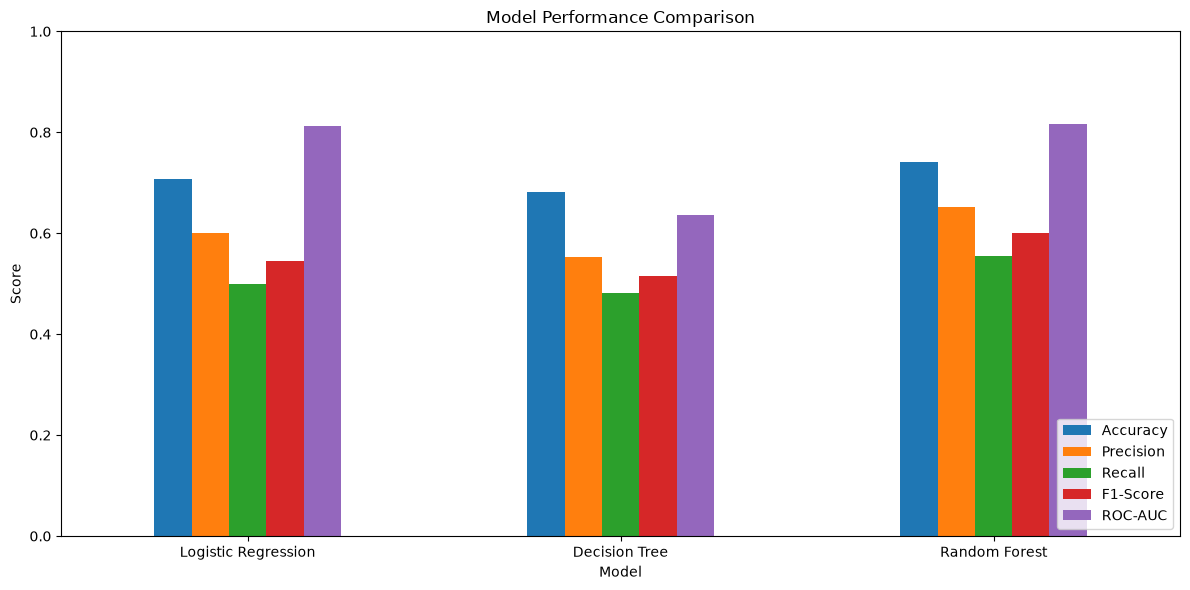

In [42]:
metrics_to_plot = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score",
    "ROC-AUC"
]

results_plot = results_df.set_index("Model")[metrics_to_plot]

results_plot.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

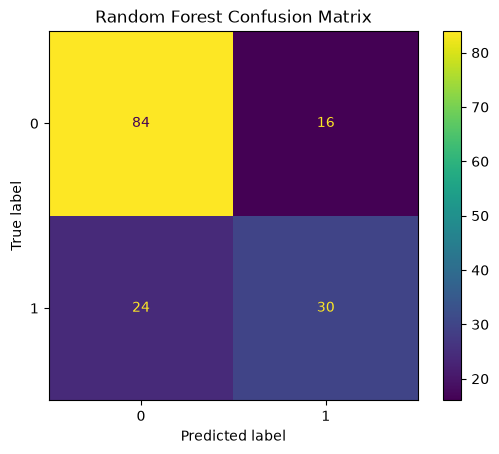

In [43]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_forest
)

plt.title("Random Forest Confusion Matrix")
plt.show()

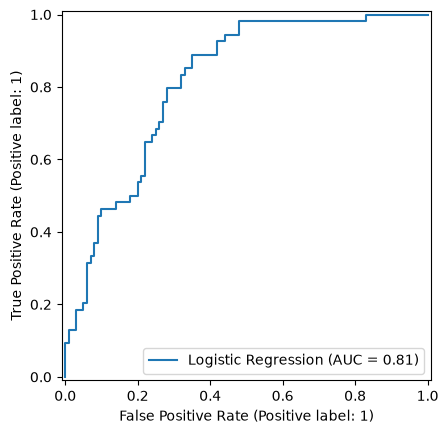

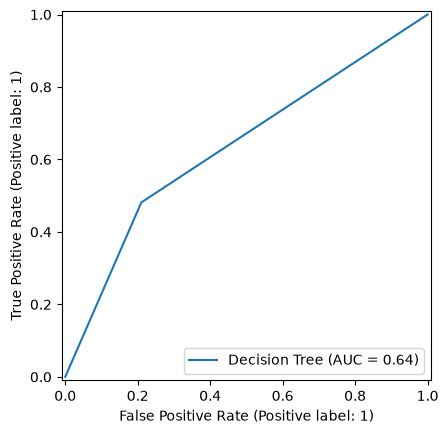

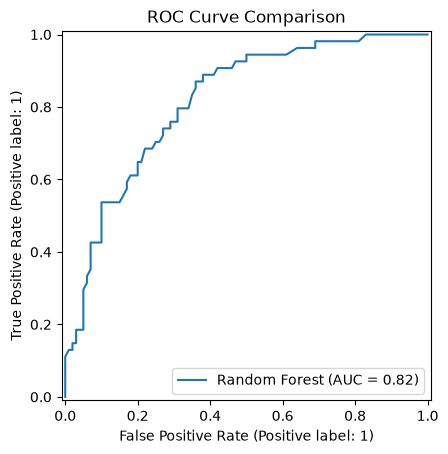

In [44]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_logistic,
    name="Logistic Regression"
)

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_tree,
    name="Decision Tree"
)

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_forest,
    name="Random Forest"
)

plt.title("ROC Curve Comparison")
plt.show()

#### Baseline Model Comparison

Three classification algorithms were evaluated using Accuracy, Precision, Recall, F1-Score, and ROC-AUC.

The baseline comparison provides a reference point for selecting a candidate model for further optimization. The final model will be selected after considering cross-validation and hyperparameter tuning rather than relying on a single evaluation metric.

In [45]:
results_df.head()

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.707792,0.600000,0.500000,0.545455,0.812963
1,Decision Tree,0.681818,0.553191,0.481481,0.514851,0.635741
2,Random Forest,0.740260,0.652174,0.555556,0.600000,0.816111


#### 4. Model Optimization

The baseline models are further evaluated using stratified cross-validation and hyperparameter tuning to improve generalization and identify the most robust model.

In [46]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_models = {
    "Logistic Regression": logistic_model,
    "Decision Tree": decision_tree_model,
    "Random Forest": random_forest_model
}

cv_results = []

for name, model in cv_models.items():
    scores = cross_val_score(
        model,
        X_train_scaled,
        y_train,
        cv=cv,
        scoring="roc_auc"
    )

    cv_results.append({
        "Model": name,
        "Mean ROC-AUC": scores.mean(),
        "Std ROC-AUC": scores.std()
    })

cv_results_df = pd.DataFrame(cv_results)

cv_results_df

,Model,Mean ROC-AUC,Std ROC-AUC
0,Logistic Regression,0.842834,0.018955
1,Decision Tree,0.641530,0.012191
2,Random Forest,0.822185,0.022625


In [47]:
from sklearn.model_selection import GridSearchCV

rf_param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 5, 10, 15],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}
rf_grid = GridSearchCV(
    estimator=RandomForestClassifier(
        random_state=42
    ),
    param_grid=rf_param_grid,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)
rf_grid.fit(X_train_scaled, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 5, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Su

In [48]:
print("Best Parameters:")
print(rf_grid.best_params_)
print("Best Cross-Validation ROC-AUC:")
print(rf_grid.best_score_)
best_rf = rf_grid.best_estimator_

Best Parameters:
{'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 300}
Best Cross-Validation ROC-AUC:
0.8406367663344408


In [49]:
tuned_rf_pred = best_rf.predict(X_test_scaled)

tuned_rf_prob = best_rf.predict_proba(
    X_test_scaled
)[:, 1]

tuned_rf_results = {
    "Accuracy": accuracy_score(y_test, tuned_rf_pred),
    "Precision": precision_score(y_test, tuned_rf_pred),
    "Recall": recall_score(y_test, tuned_rf_pred),
    "F1-Score": f1_score(y_test, tuned_rf_pred),
    "ROC-AUC": roc_auc_score(y_test, tuned_rf_prob)
}

tuned_rf_results

{'Accuracy': 0.7207792207792207,
 'Precision': 0.6341463414634146,
 'Recall': 0.48148148148148145,
 'F1-Score': 0.5473684210526316,
 'ROC-AUC': 0.8066666666666666}

In [50]:
comparison = pd.DataFrame([
    {
        "Model": "Baseline Random Forest",
        **results_df[
            results_df["Model"] == "Random Forest"
        ].iloc[0].drop("Model").to_dict()
    },
    {
        "Model": "Tuned Random Forest",
        **tuned_rf_results
    }
])

comparison

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Baseline Random Forest,0.740260,0.652174,0.555556,0.600000,0.816111
1,Tuned Random Forest,0.720779,0.634146,0.481481,0.547368,0.806667


#### 4. Model Optimization

The baseline models are further evaluated using stratified cross-validation and hyperparameter tuning to improve generalization and identify the most robust model.

In [51]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)
cv_models = {
    "Logistic Regression": logistic_model,
    "Decision Tree": decision_tree_model,
    "Random Forest": random_forest_model
}

cv_results = []

for name, model in cv_models.items():
    scores = cross_val_score(
        model,
        X_train_scaled,
        y_train,
        cv=cv,
        scoring="roc_auc"
    )

    cv_results.append({
        "Model": name,
        "Mean ROC-AUC": scores.mean(),
        "Std ROC-AUC": scores.std()
    })

cv_results_df = pd.DataFrame(cv_results)

cv_results_df

,Model,Mean ROC-AUC,Std ROC-AUC
0,Logistic Regression,0.842834,0.018955
1,Decision Tree,0.641530,0.012191
2,Random Forest,0.822185,0.022625


In [52]:
from sklearn.model_selection import GridSearchCV

rf_param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 5, 10, 15],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

rf_grid = GridSearchCV(
    estimator=RandomForestClassifier(
        random_state=42
    ),
    param_grid=rf_param_grid,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

rf_grid.fit(X_train_scaled, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 5, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Su

In [53]:
print("Best Parameters:")
print(rf_grid.best_params_)

Best Parameters:
{'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 300}


In [54]:
print("Best Cross-Validation ROC-AUC:")
print(rf_grid.best_score_)

Best Cross-Validation ROC-AUC:
0.8406367663344408


In [55]:
best_rf = rf_grid.best_estimator_

In [56]:
tuned_rf_pred = best_rf.predict(X_test_scaled)

tuned_rf_prob = best_rf.predict_proba(
    X_test_scaled
)[:, 1]

tuned_rf_results = {
    "Accuracy": accuracy_score(y_test, tuned_rf_pred),
    "Precision": precision_score(y_test, tuned_rf_pred),
    "Recall": recall_score(y_test, tuned_rf_pred),
    "F1-Score": f1_score(y_test, tuned_rf_pred),
    "ROC-AUC": roc_auc_score(y_test, tuned_rf_prob)
}

tuned_rf_results

{'Accuracy': 0.7207792207792207,
 'Precision': 0.6341463414634146,
 'Recall': 0.48148148148148145,
 'F1-Score': 0.5473684210526316,
 'ROC-AUC': 0.8066666666666666}

In [57]:
comparison = pd.DataFrame([
    {
        "Model": "Baseline Random Forest",
        **results_df[
            results_df["Model"] == "Random Forest"
        ].iloc[0].drop("Model").to_dict()
    },
    {
        "Model": "Tuned Random Forest",
        **tuned_rf_results
    }
])

comparison

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Baseline Random Forest,0.740260,0.652174,0.555556,0.600000,0.816111
1,Tuned Random Forest,0.720779,0.634146,0.481481,0.547368,0.806667


#### Logistic Regression Hyperparameter Tuning

Since Logistic Regression achieved the highest mean cross-validation ROC-AUC among the baseline models, its regularization strength is further optimized using GridSearchCV.

In [58]:
from sklearn.model_selection import GridSearchCV

lr_param_grid = {
    "C": [0.01, 0.1, 1, 10, 100],
    "solver": ["liblinear", "lbfgs"]
}

lr_grid = GridSearchCV(
    estimator=LogisticRegression(
        random_state=42,
        max_iter=1000
    ),
    param_grid=lr_param_grid,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

lr_grid.fit(X_train_scaled, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.01, 0.1, ...], 'solver': ['liblinear', 'lbfgs']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Control

In [59]:
print("Best Logistic Regression Parameters:")
print(lr_grid.best_params_)

Best Logistic Regression Parameters:
{'C': 0.1, 'solver': 'lbfgs'}


In [60]:
print("Best Logistic Regression CV ROC-AUC:")
print(lr_grid.best_score_)

Best Logistic Regression CV ROC-AUC:
0.844327242524917


In [61]:
best_lr = lr_grid.best_estimator_

tuned_lr_pred = best_lr.predict(X_test_scaled)

tuned_lr_prob = best_lr.predict_proba(
    X_test_scaled
)[:, 1]

tuned_lr_results = {
    "Accuracy": accuracy_score(y_test, tuned_lr_pred),
    "Precision": precision_score(y_test, tuned_lr_pred),
    "Recall": recall_score(y_test, tuned_lr_pred),
    "F1-Score": f1_score(y_test, tuned_lr_pred),
    "ROC-AUC": roc_auc_score(y_test, tuned_lr_prob)
}

tuned_lr_results

{'Accuracy': 0.6883116883116883,
 'Precision': 0.5652173913043478,
 'Recall': 0.48148148148148145,
 'F1-Score': 0.52,
 'ROC-AUC': 0.8105555555555556}

In [ ]:
final_comparison = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        **results_df[
            results_df["Model"] == "Logistic Regression"
        ].iloc[0].drop("Model").to_dict()
    },
    {
        "Model": "Tuned Logistic Regression",
        **tuned_lr_results
    },
    {
        "Model": "Random Forest",
        **results_df[
            results_df["Model"] == "Random Forest"
        ].iloc[0].drop("Model").to_dict()
    },
    {
        "Model": "Tuned Random Forest",
        **tuned_rf_results
    }
])

final_comparison